<a href="https://colab.research.google.com/github/rahna1369/ML-India-Weather-prediction-project/blob/main/india_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)


# DATA PREPROCESSING & EDA


## 1. Data Loading & Inspection


###Explanation:
The dataset is loaded using pandas. The first few rows are displayed to understand the structure of the data.

In [51]:
# Load the dataset
df = pd.read_csv("popular_cities_weather.csv")

In [52]:
# Display the first 5 rows
print("--- FIRST 5 ROWS ---")
print(df.head())

--- FIRST 5 ROWS ---
                  date  tavg  tmin  tmax  prcp  wspd    pres     tsun    city
0  2020-01-01 00:00:00  24.9  19.2  29.9   0.0   NaN  1013.4  13800.0  Mumbai
1  2020-02-01 00:00:00  27.3  21.0  32.6   0.0   NaN  1012.7  11220.0  Mumbai
2  2020-03-01 00:00:00  27.7  22.6  31.9   0.0   NaN  1011.2  12900.0  Mumbai
3  2020-04-01 00:00:00  30.2  26.4  33.9   0.0   NaN  1009.6  14220.0  Mumbai
4  2020-05-01 00:00:00  31.1  28.6  34.0   0.0   NaN  1007.3  15960.0  Mumbai


###Explanation:
Data inspection is performed to check total number of rows & columns, column names, data types and basic statistical information.

In [53]:
# Check the total number of rows & columns
print(df.shape)

(7056, 9)


In [54]:
# Column names
print(df.columns)

Index(['date', 'tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres', 'tsun', 'city'], dtype='object')


In [55]:
# Cities names
df["city"].unique()

array(['Mumbai', 'Delhi', 'Bengaluru', 'Ahmedabad', 'Hyderabad',
       'Chennai', 'Kolkata', 'Pune', 'Jaipur', 'Surat', 'Lucknow',
       'Kanpur', 'Nagpur', 'Patna', 'Indore', 'Thane', 'Bhopal',
       'Visakhapatnam', 'Vadodara', 'Firozabad', 'Ludhiana', 'Rajkot',
       'Agra', 'Siliguri', 'Nashik', 'Faridabad', 'Patiala', 'Meerut',
       'Kalyan-Dombivli', 'Vasai-Virar', 'Varanasi', 'Srinagar',
       'Dhanbad', 'Jodhpur', 'Amritsar', 'Raipur', 'Allahabad',
       'Coimbatore', 'Jabalpur', 'Gwalior', 'Vijayawada', 'Madurai',
       'Guwahati', 'Chandigarh', 'Amroha', 'Moradabad', 'Gurgaon',
       'Aligarh', 'Solapur', 'Ranchi', 'Jalandhar', 'Tiruchirappalli',
       'Bhubaneswar', 'Salem', 'Warangal', 'Thiruvananthapuram',
       'Bhiwandi', 'Saharanpur', 'Guntur', 'Amravati', 'Bikaner', 'Noida',
       'Jamshedpur', 'Bhilai', 'Cuttack', 'Firozpur', 'Kochi', 'Nellore',
       'Bhavnagar', 'Dehradun', 'Durgapur', 'Asansol', 'Rourkela',
       'Nanded', 'Kolhapur', 'Ajmer', 'Akola

In [56]:
# Check data types, non-null counts, and memory usage of the dataset
print("--- DATASET SUMMARY ---")
print(df.info())

--- DATASET SUMMARY ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7056 entries, 0 to 7055
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    7056 non-null   object 
 1   tavg    6517 non-null   float64
 2   tmin    6452 non-null   float64
 3   tmax    6431 non-null   float64
 4   prcp    6126 non-null   float64
 5   wspd    0 non-null      float64
 6   pres    6434 non-null   float64
 7   tsun    2405 non-null   float64
 8   city    7056 non-null   object 
dtypes: float64(7), object(2)
memory usage: 496.3+ KB
None


In [57]:
# Descriptive statistical analysis
print("\n--- DESCRIPTIVE STATISTICS ---")
print(df.describe())


--- DESCRIPTIVE STATISTICS ---
              tavg         tmin         tmax         prcp  wspd         pres  \
count  6517.000000  6452.000000  6431.000000  6126.000000   0.0  6434.000000   
mean     25.896179    20.843971    31.630944   117.887055   NaN  1008.847606   
std       5.220012     5.724433     5.035931   180.628768   NaN     5.308233   
min       0.600000    -4.500000     5.700000     0.000000   NaN   994.800000   
25%      23.300000    17.200000    29.300000     3.000000   NaN  1004.400000   
50%      27.100000    22.600000    32.000000    45.000000   NaN  1009.200000   
75%      29.500000    25.300000    34.700000   169.500000   NaN  1013.300000   
max      36.600000    31.000000    44.000000  1768.900000   NaN  1025.900000   

               tsun  
count   2405.000000  
mean   10584.997921  
std     3864.452460  
min     1020.000000  
25%     7680.000000  
50%    10740.000000  
75%    13620.000000  
max    21360.000000  


## 2. Handling Missing Values


###2.1: Counting Missing Values

###Explanation:
Missing values were checked using isnull().sum() and percentage calculation.

In [58]:
# check the total no.of missing null values in each column
print("\n--- MISSING VALUE COUNT PER COLUMN ---")
print(df.isnull().sum())


--- MISSING VALUE COUNT PER COLUMN ---
date       0
tavg     539
tmin     604
tmax     625
prcp     930
wspd    7056
pres     622
tsun    4651
city       0
dtype: int64


In [59]:
# Calculate the percentage of missing data
missing_percentage = (df.isnull().sum() / len(df)) * 100
print("\n--- Percentage of Missing Data ---")
print(missing_percentage)


--- Percentage of Missing Data ---
date      0.000000
tavg      7.638889
tmin      8.560091
tmax      8.857710
prcp     13.180272
wspd    100.000000
pres      8.815193
tsun     65.915533
city      0.000000
dtype: float64


In [60]:
# check the total no.of missing null values in each rows
print("\n--- MISSING VALUE COUNT PER ROws ---")
print(df.isnull().sum(axis=1))


--- MISSING VALUE COUNT PER ROws ---
0       1
1       1
2       1
3       1
4       1
       ..
7051    2
7052    2
7053    2
7054    2
7055    2
Length: 7056, dtype: int64


In [61]:
# Calculate percentage of missing data in each row
missing_row_pct = (df.isnull().mean(axis=1) * 100).round(2)

# Show the top 10 rows with the highest percentage of missing data
print("Missing values from row in highest Percentage ")
missing_row_pct.sort_values(ascending=False).head(10)

Missing values from row in highest Percentage 


,0
4761,77.78
6995,77.78
6994,77.78
4756,77.78
4752,77.78
4598,77.78
4591,77.78
4547,77.78
4546,77.78
4545,77.78


#### 2.3: Visualizing Missing Data using Heatmap

A *heatmap* is a graphical representation of data where individual values contained in a matrix are represented as colors.


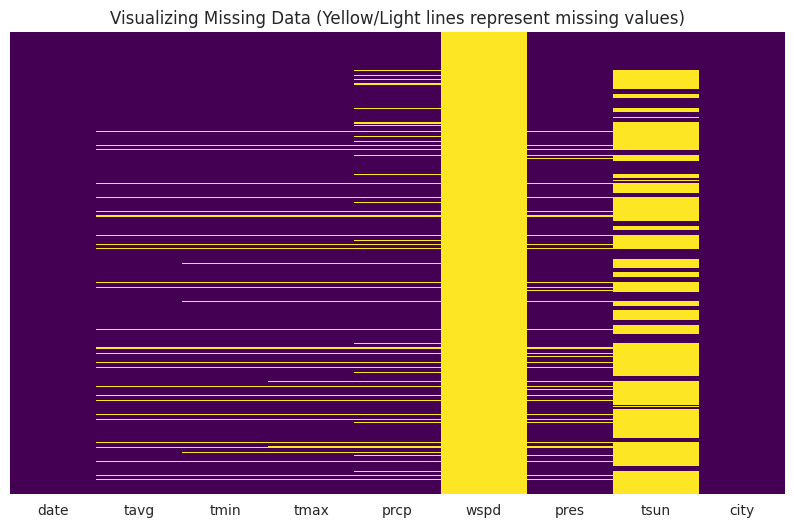

In [62]:
# Create a heatmap of missing values
plt.figure(figsize=(10, 6))

# cbar=False removes the color bar legend, yticklabels=False hides individual row numbers for clarity
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")

plt.title("Visualizing Missing Data (Yellow/Light lines represent missing values)")
plt.show()

**Interpretation:** The missing value heatmap shows missing data in the dataset. Yellow/light lines represent missing values, while dark areas represent available values. Columns with too many missing values, such as wspd and tsun, were removed, and other missing values were handled during preprocessing.

## 3. Visualizing Data Distribution Analysis

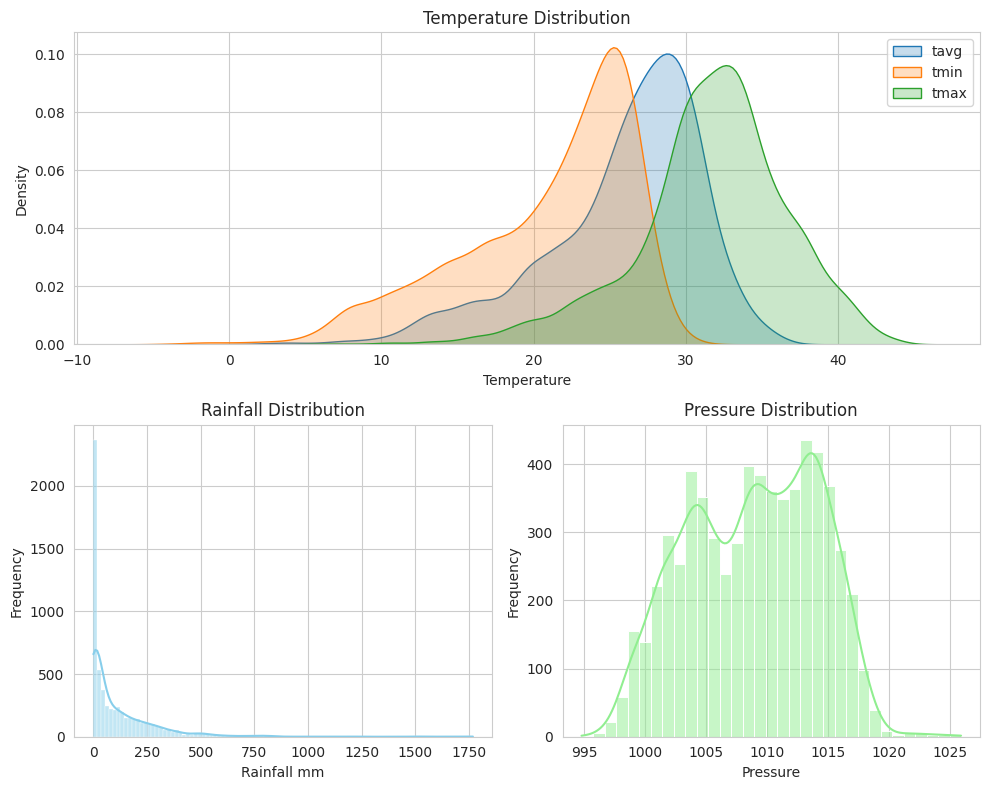

In [63]:
# Sets the background styleof the plots to have clean grid for easier reading
sns.set_style("whitegrid")

# Initializes the figure canvas size
fig = plt.figure(figsize=(10, 8))

# ----Temperature distribution------

# Creates a gird of 2 rows and 1 columns and palaces this plot in 1st position
plt.subplot(2, 1, 1)

# Plots the kernal density Estimate (KDE) for average minimum, & maximum Temperature
# fill=True shades area under the curves to make overlapping zones visually clear
sns.kdeplot(df["tavg"], label="tavg", fill=True)
sns.kdeplot(df["tmin"], label="tmin", fill=True)
sns.kdeplot(df["tmax"], label="tmax", fill=True)

# Adds structural labels and a legend to identify which curve belongs to which variable
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Density")
plt.legend()

# -----Rainfall distribution-----

# Creates a grid of 2 rows and 2 columns, and places this plot in the 3rd position (bottom left)
plt.subplot(2, 2, 3)

# Plots a histogram for precipitation (prcp) to see daily rainfall frequencies.
# kde=True overlays a smooth trend line, and color="skyblue" styles the bins.
sns.histplot(df["prcp"], kde=True, color="skyblue")
plt.title("Rainfall Distribution")
plt.xlabel("Rainfall mm")
plt.ylabel("Frequency")

# -----Pressure distribution----

# Places this plot in the 4th position of the 2x2 grid (bottom right)
plt.subplot(2, 2, 4)

# Plots a histogram and a smooth trend line for atmospheric pressure (pres) using light green bins.
sns.histplot(df["pres"], kde=True, color="lightgreen")
plt.title("Pressure Distribution")
plt.xlabel("Pressure")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Interpretation:**
 The distribution plot shows that tmin, tavg, and tmax follow a clear temperature pattern, where minimum temperature is lower, average temperature is in the middle, and maximum temperature is higher. The rainfall distribution is highly skewed, meaning most records have low rainfall and only a few records have very high rainfall. The pressure distribution is more spread out but mostly concentrated around common atmospheric pressure values. This shows why rainfall needs log transformation before model training.

## 4. Data Cleaning

Columns with very high missing values were removed. The wspd column was dropped because it had 100% missing values, and tsun was dropped because it had many missing values. Rows with missing target value tavg and were removed. Missing values in feature columns such as tmin, tmax, prcp, and pres were filled using median because median is less affected by outliers.

#### 4.1: Removing Duplicates

In [64]:
# Check for duplicate rows
print(f"Duplicate rows: {df.duplicated().sum()}")

# Remove duplicate rows, keeping the first occurrence
df.drop_duplicates(inplace=True)

Duplicate rows: 144


#### 4.2: Drop Weak Columns & Rows

In [65]:
# Drop the colums that have massive missing value
df.drop(columns=['wspd', 'tsun'], errors='ignore', inplace=True)

# Drop rows
df = df.dropna(subset=["tavg","prcp"])
print(df.shape)
df.head()


(5999, 7)


,date,tavg,tmin,tmax,prcp,pres,city
0,2020-01-01 00:00:00,24.9,19.2,29.9,0.0,1013.4,Mumbai
1,2020-02-01 00:00:00,27.3,21.0,32.6,0.0,1012.7,Mumbai
2,2020-03-01 00:00:00,27.7,22.6,31.9,0.0,1011.2,Mumbai
3,2020-04-01 00:00:00,30.2,26.4,33.9,0.0,1009.6,Mumbai
4,2020-05-01 00:00:00,31.1,28.6,34.0,0.0,1007.3,Mumbai


#### 4.3: Data type formatting

In [66]:
# Convert the 'date' column to a proper datetime format
df['date'] = pd.to_datetime(df['date'])


#### 4.4: Feature Engineering


**Explanation**:
 The city column contains text values. Machine learning models require numerical input, so the city column is converted into numbers using label encoding.

4.4.1: Data Extraction

In [67]:
#  Feature Engineering: Extract Month and Year
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df.head()

,date,tavg,tmin,tmax,prcp,pres,city,year,month
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5


4.4.2: Visualizing Monthly Temperature

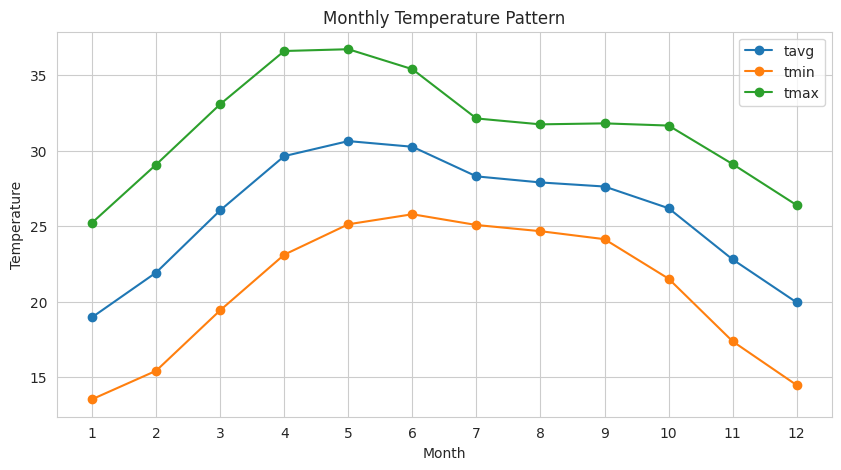

In [68]:
# Calculate the monthly mean
monthly_temp = df.groupby("month")[["tavg", "tmin", "tmax"]].mean()

# Initialize the plot
plt.figure(figsize=(10, 5))

# Plot all three lines simultaneously with markers
plt.plot(monthly_temp.index, monthly_temp["tavg"], marker="o", label="tavg")
plt.plot(monthly_temp.index, monthly_temp["tmin"], marker="o", label="tmin")
plt.plot(monthly_temp.index, monthly_temp["tmax"], marker="o", label="tmax")

# Enhance typography and labels
plt.title("Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature")

# [Jan, Feb, mar.....]
plt.xticks(range(1, 13))
plt.legend()
plt.show()

**Interpretation:**
The monthly temperature pattern shows that temperatures increase from January and reach the highest levels around April to June. After June, the temperature gradually decreases toward December. The tmin, tavg, and tmax lines follow a similar seasonal trend, showing that temperature changes consistently across the year.

4.4.3: Visualizing Monthly Average Rainfall

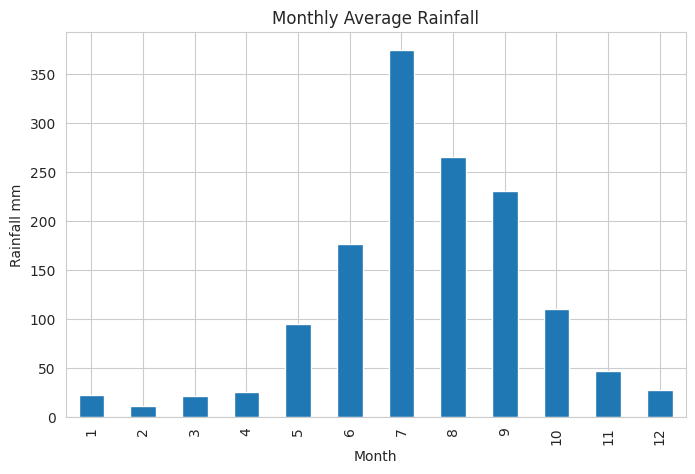

In [69]:
# Group the dataset by the 'month' column and calculate the mean for precipitation ('prcp')
monthly_rain = df.groupby("month")["prcp"].mean()

plt.figure(figsize=(8, 5))

# Plot the aggregated pandas Series as a vertical bar chart
monthly_rain.plot(kind="bar")

plt.title("Monthly Average Rainfall")  # Add a title to the top of the chart
plt.xlabel("Month")                   # Label the horizontal x-axis
plt.ylabel("Rainfall mm")              # Label the vertical y-axis (including units)
plt.show()

The monthly rainfall graph shows that rainfall is low from January to April, then increases from May. The highest rainfall occurs in July, followed by high rainfall in August and September. After September, rainfall gradually decreases toward December. This pattern shows a clear seasonal rainfall trend.

4.4.4: Encode Categorical Column

**Explanation:**  The city column contains text values, but machine learning models require numerical input. Therefore, the city names were converted into numerical values using label encoding. Also, the rainfall column prcp was converted into a new classification target called rain_status, where 1 represents Rain and 0 represents No Rain. This helps the model predict whether rainfall will occur or not.

In [70]:
# Initialize the LabelEncoder
encoder = LabelEncoder()

# Convert the text city column into numeric code
df["city_encoded"] = encoder.fit_transform(df["city"])
df.head()

,date,tavg,tmin,tmax,prcp,pres,city,year,month,city_encoded
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1,62
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2,62
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3,62
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4,62
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5,62


In [71]:
# Binary Encoding for precipitation
# If precipitation ('prcp') is greater than 0, assign 1 (Rainy); otherwise, assign 0 (Dry)
df["rain_status"] = np.where(df["prcp"] > 0, 1, 0)

print(df[["prcp", "rain_status"]].head())

   prcp  rain_status
0   0.0            0
1   0.0            0
2   0.0            0
3   0.0            0
4   0.0            0


4.4.5: Visualizing Top 10 Hottest Cities

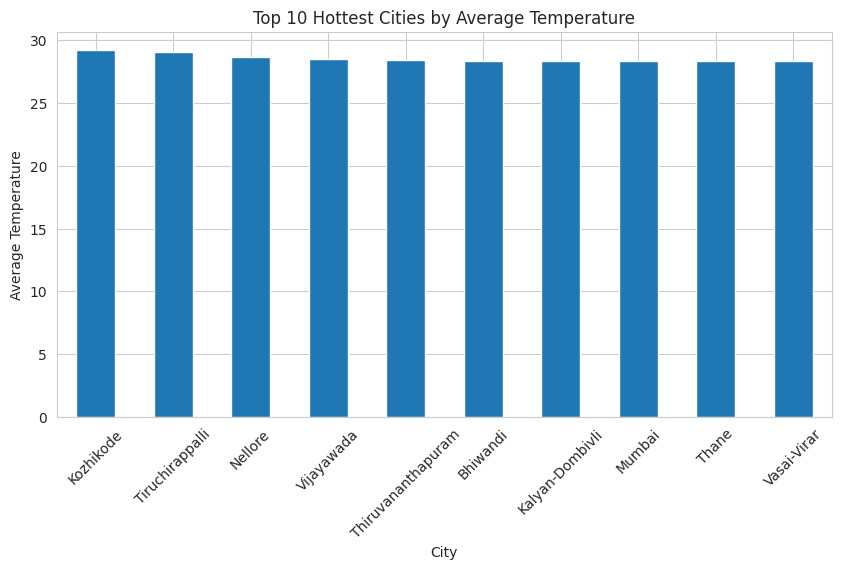

In [72]:
top_hot_cities = df.groupby("city")["tavg"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

top_hot_cities.plot(kind="bar")

plt.title("Top 10 Hottest Cities by Average Temperature")
plt.xlabel("City")
plt.ylabel("Average Temperature")
plt.xticks(rotation=45)
plt.show()

The graph shows the top 10 hottest cities based on average temperature. Kozhikode has the highest average temperature, followed by Tiruchirappalli and Nellore. Most of the top cities have similar average temperatures, around 28°C to 29°C. This helps identify the cities with consistently warmer weather conditions.

4.4.6: Visualizing Top 10 Rainiest Cities

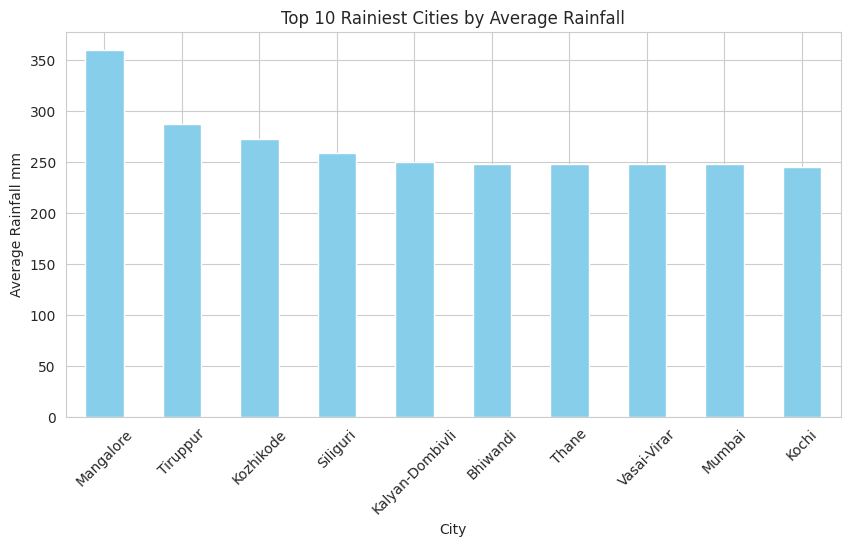

In [73]:
top_rainy_cities = df.groupby("city")["prcp"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))

top_rainy_cities.plot(kind="bar", color="skyblue")

plt.title("Top 10 Rainiest Cities by Average Rainfall")
plt.xlabel("City")
plt.ylabel("Average Rainfall mm")
plt.xticks(rotation=45)
plt.show()

The graph shows the top 10 rainiest cities based on average rainfall. Mangalore has the highest average rainfall, followed by Tiruppur and Kozhikode. Kochi is also included in the top 10 rainiest cities, showing that it receives relatively high rainfall compared to other cities in the dataset.

###4.5: Median Imputatiom

In [74]:
# Specify the list of columns that contain missing (NaN) values needing imputation
missing_value_cols = ["tmin", "tmax", "prcp", "pres"]

# Calculate and Fill Missing Values
df[missing_value_cols] = df[missing_value_cols].fillna(
    df[missing_value_cols].median())
df

,date,tavg,tmin,tmax,prcp,pres,city,year,month,city_encoded,rain_status
0,2020-01-01,24.9,19.2,29.9,0.0,1013.4,Mumbai,2020,1,62,0
1,2020-02-01,27.3,21.0,32.6,0.0,1012.7,Mumbai,2020,2,62,0
2,2020-03-01,27.7,22.6,31.9,0.0,1011.2,Mumbai,2020,3,62,0
3,2020-04-01,30.2,26.4,33.9,0.0,1009.6,Mumbai,2020,4,62,0
4,2020-05-01,31.1,28.6,34.0,0.0,1007.3,Mumbai,2020,5,62,0
...,...,...,...,...,...,...,...,...,...,...,...
7051,2025-08-01,20.8,18.0,24.8,321.1,1007.4,Shimla,2025,8,78,1
7052,2025-09-01,19.8,16.3,24.3,150.9,1009.4,Shimla,2025,9,78,1
7053,2025-10-01,15.9,10.6,22.6,61.5,1015.1,Shimla,2025,10,78,1
7054,2025-11-01,11.6,6.1,19.4,2.4,1017.8,Shimla,2025,11,78,1


## 5. Outlier Detection & Handling

Outliers were identified using boxplots. The IQR capping method was used to handle extreme values. This method replaces values below the lower limit and above the upper limit instead of deleting rows, helping to preserve the size of the dataset.

### 5.1: Outlier Detection Before Handling (Boxplot)

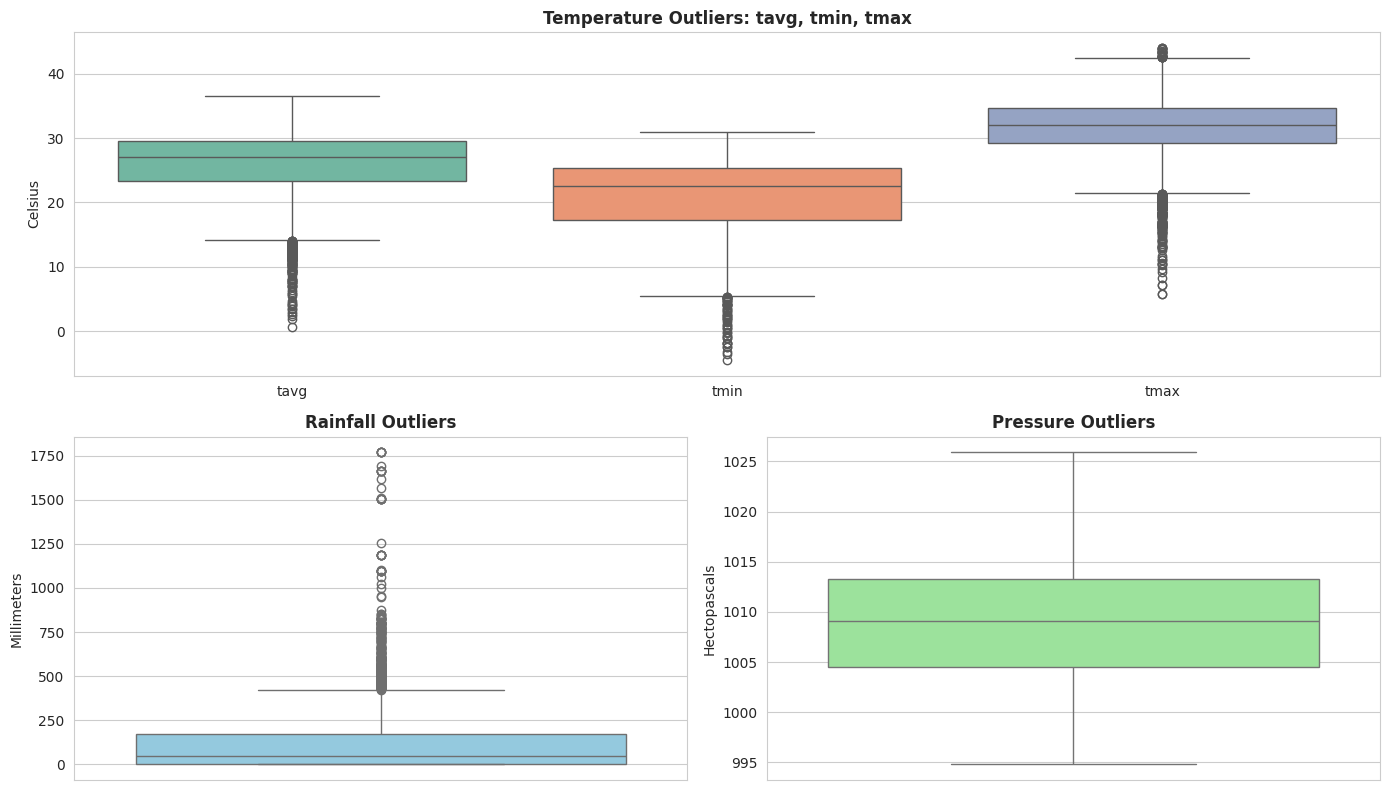

In [75]:
sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 8))

# Temperature plot - full width
plt.subplot(2, 1, 1)
sns.boxplot(data=df[["tavg", "tmin", "tmax"]], palette="Set2")
plt.title("Temperature Outliers: tavg, tmin, tmax", fontweight="bold")
plt.ylabel("Celsius")

# Rainfall plot
plt.subplot(2, 2, 3)
sns.boxplot(y=df["prcp"], color="skyblue")
plt.title("Rainfall Outliers", fontweight="bold")
plt.ylabel("Millimeters")

# Pressure plot
plt.subplot(2, 2, 4)
sns.boxplot(y=df["pres"], color="lightgreen")
plt.title("Pressure Outliers", fontweight="bold")
plt.ylabel("Hectopascals")

plt.tight_layout()
plt.show()

The boxplots show the presence of outliers in the weather variables. Temperature columns have some low and high outliers, especially in tavg, tmin, and tmax. Rainfall has many extreme outliers, showing that some records have very high rainfall values. Pressure has fewer outliers compared to rainfall.

###5.2: Handle Outliers using IQR capping

In [76]:
# Define the function to cap outliers for Temperature and Pressure
def cap_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(data[column] < lower_limit, lower_limit, data[column])
    data[column] = np.where(data[column] > upper_limit, upper_limit, data[column])

    return data

outlier_columns = ["tavg", "tmin", "tmax", "prcp", "pres"]

for col in outlier_columns:
    df = cap_outliers_iqr(df, col)

print("Outlier handling completed.")

Outlier handling completed.


### 5.3: Handling outliers using log transformation(Skewed Data)


In [77]:
# Use np.log1p (log of x + 1) to handle 0 values and compress right-skewed rainfall data
df["prcp_log"] = np.log1p(df["prcp"])

# Print the skewness coefficient of the original precipitation data
print("Rainfall skewness before log:", df["prcp"].skew())

# Print the skewness coefficient after the transformation to verify normalization
print("Rainfall skewness after log:", df["prcp_log"].skew())

Rainfall skewness before log: 1.217246674265326
Rainfall skewness after log: -0.38771307984985415


### 5.4: Visualization Before and after log transformation(Histogram)

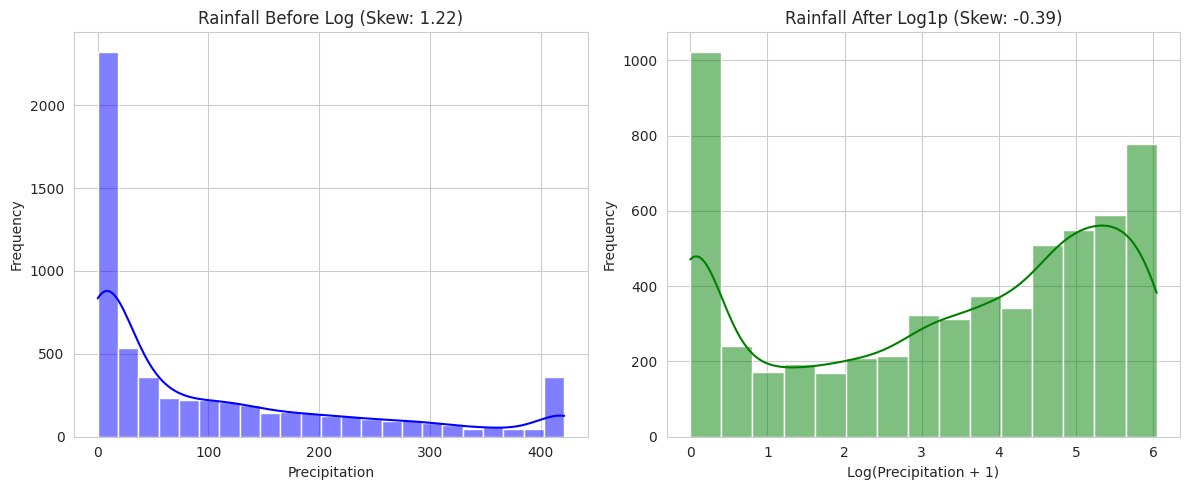

In [78]:
# Set up a 1-row, 2-column plotting area
plt.figure(figsize=(12, 5))

# 1. Left Subplot: Before Transformation
plt.subplot(1, 2, 1)
sns.histplot(df["prcp"], kde=True, color="blue")
plt.title(f'Rainfall Before Log (Skew: {df["prcp"].skew():.2f})')
plt.xlabel("Precipitation")
plt.ylabel("Frequency")

# 2. Right Subplot: After Log Transformation
plt.subplot(1, 2, 2)
sns.histplot(df["prcp_log"], kde=True, color="green")
plt.title(f'Rainfall After Log1p (Skew: {df["prcp_log"].skew():.2f})')
plt.xlabel("Log(Precipitation + 1)")
plt.ylabel("Frequency")

# Adjust spacing and display
plt.tight_layout()
plt.show()

The rainfall distribution before log transformation is positively skewed, meaning most rainfall values are low while a few values are very high. After applying log1p, the skewness is reduced from 1.22 to -0.39, making the rainfall distribution more balanced. This helps improve model performance and reduces the effect of extreme rainfall values.

###5.5:  Outlier Detection After Handling (Boxplot)

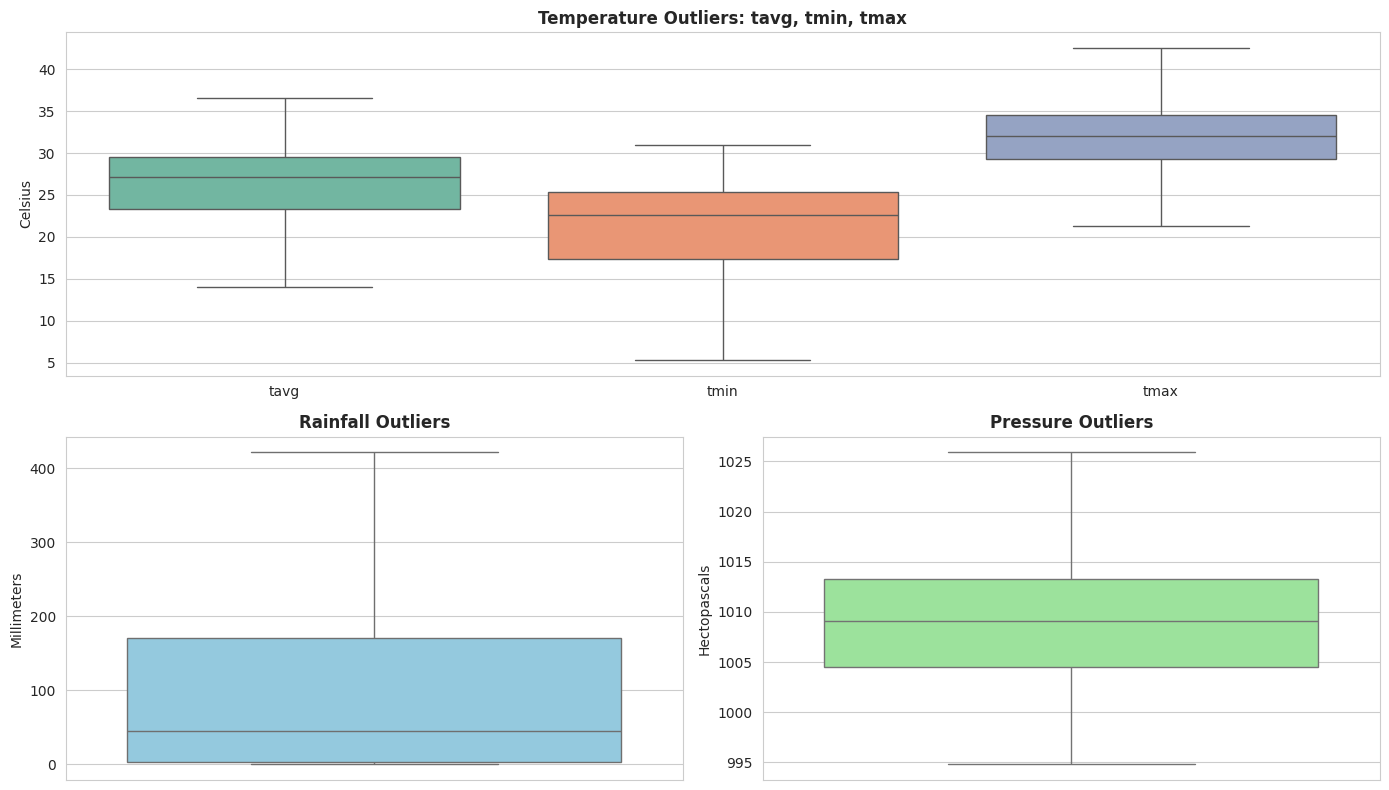

In [79]:
sns.set_style("whitegrid")

fig = plt.figure(figsize=(14, 8))

# Temperature plot - full width
plt.subplot(2, 1, 1)
sns.boxplot(data=df[["tavg", "tmin", "tmax"]], palette="Set2")
plt.title("Temperature Outliers: tavg, tmin, tmax", fontweight="bold")
plt.ylabel("Celsius")

# Rainfall plot
plt.subplot(2, 2, 3)
sns.boxplot(y=df["prcp"], color="skyblue")
plt.title("Rainfall Outliers", fontweight="bold")
plt.ylabel("Millimeters")

# Pressure plot
plt.subplot(2, 2, 4)
sns.boxplot(y=df["pres"], color="lightgreen")
plt.title("Pressure Outliers", fontweight="bold")
plt.ylabel("Hectopascals")

plt.tight_layout()
plt.show()

After outlier handling, extreme values were reduced. The data is now more balanced and suitable for model training. IQR capping helped control outliers without deleting rows.

## 6. Feature Selection

Feature selection was performed to choose the most useful input columns for prediction. Correlation analysis was used to understand the relationship between features and the target variable. Features such as minimum temperature, maximum temperature, rainfall, pressure, city, year, and month were selected for model training.

###6.1: Correlation (Heatmap)

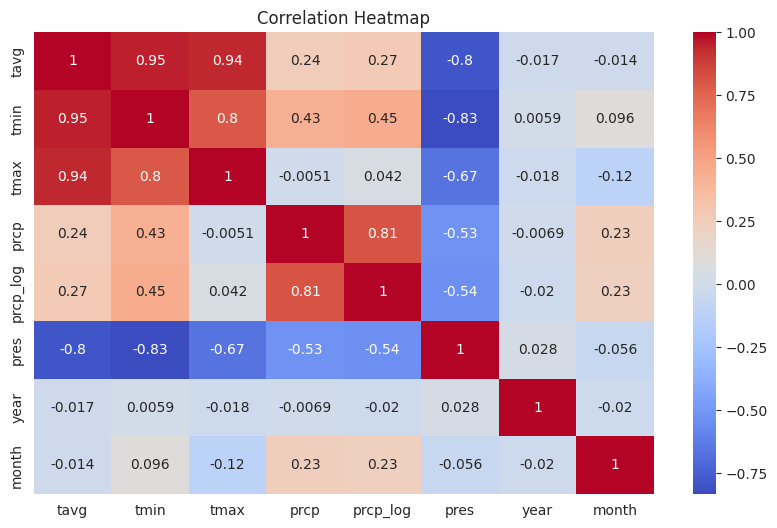

In [80]:
# Define the list of continuous variables to include in the correlation analysis
corr_cols = [ "tavg", "tmin", "tmax","prcp","prcp_log","pres", "year","month"]
plt.figure(figsize=(10, 6))

# Calculate the Pearson correlation matrix using .corr() and render it as a heatmap
# 'annot=True' displays the correlation coefficients inside the squares
# 'cmap="coolwarm"' applies a color gradient ranging from blue (negative) to red (positive)
sns.heatmap(df[corr_cols].corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

The heatmap shows a strong positive correlation between tavg, tmin, and tmax, meaning temperature variables are closely related. Pressure has a strong negative correlation with temperature, so when temperature increases, pressure tends to decrease. Rainfall has a moderate relationship with prcp_log, but year and month show weak correlation with most variables.

## 7. Splitting Data into Training and Testing sets

The dataset was divided into training and testing data. The training data was used to train the machine learning models, while the testing data was used to evaluate model performance. This helps check how well the model performs on unseen data.

###7.1: Split data for temperature prediction

In [81]:
# Create a list of all column names that the model will use to learn and predict temperature
temperature_features = [ "tmin","tmax","prcp_log","pres","city_encoded","year","month"]

# Set 'tavg' (average temperature) as the target column we want the model to predict
X_temp = df[temperature_features]
y_temp = df["tavg"]

# Divide data into training (80%) and testing (20%) sets
# 'test_size=0.2' allocates 20% of rows for evaluation
# 'random_state=42' ensures the shuffle split is identical every time the code runs
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X_temp,
    y_temp,
    test_size=0.2,
    random_state=42)

print("Temperature Train:", X_train_temp.shape)
print("Temperature Test:", X_test_temp.shape)

Temperature Train: (4799, 7)
Temperature Test: (1200, 7)


###7.2: Split data for rainfall amount prediction

In [82]:
rainfall_features = [ "tavg","tmin","tmax","pres","city_encoded","year","month"]

X_rain = df[rainfall_features]
y_rain = df["prcp_log"]

X_train_rain, X_test_rain, y_train_rain, y_test_rain = train_test_split(
    X_rain,
    y_rain,
    test_size=0.2,
    random_state=42)

print("Rainfall Train:", X_train_rain.shape)
print("Rainfall Test:", X_test_rain.shape)

Rainfall Train: (4799, 7)
Rainfall Test: (1200, 7)


###7.3: Split data for Rain / No Rain classification

In [83]:
df["rain_status"] = np.where(df["prcp"] > 0, 1, 0)

classification_features = [ "tavg", "tmin","tmax","pres","city_encoded", "year","month"]

X_class = df[classification_features]
y_class = df["rain_status"]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42,
    stratify=y_class)

print("Classification Train:", X_train_class.shape)
print("Classification Test:", X_test_class.shape)

Classification Train: (4799, 7)
Classification Test: (1200, 7)


## 8. Feature Scaling

Feature scaling was applied using StandardScaler. Scaling helps models such as Linear Regression and Logistic Regression perform better because the feature values are brought into a similar range. Random Forest models do not require scaling, but scaling was still used where needed.

In [84]:
# Temperature scaling

# Initialize the StandardScaler to normalize the temperature features (mean=0, variance=1)
temp_scaler = StandardScaler()

# Compute the mean and variance from the training set, then transform it
X_train_temp_scaled = temp_scaler.fit_transform(X_train_temp)

# Scale the test set using the exact same mean and variance computed from the training set
X_test_temp_scaled = temp_scaler.transform(X_test_temp)


# Rainfall regression scaling
rain_scaler = StandardScaler()
X_train_rain_scaled = rain_scaler.fit_transform(X_train_rain)
X_test_rain_scaled = rain_scaler.transform(X_test_rain)


# Rain / No Rain classification scaling
class_scaler = StandardScaler()
X_train_class_scaled = class_scaler.fit_transform(X_train_class)
X_test_class_scaled = class_scaler.transform(X_test_class)

print("Complete Feature scaling.")


Complete Feature scaling.


# MODEL BULIDING & TRAINING

## 9. Supervised Learning Model

Supervised learning is a machine learning technique where the model is trained using labeled data. The model learns from input features and their correct output values. In this project, supervised learning is used for temperature prediction, rainfall amount prediction, and rain/no-rain classification.

### 9.1: Temperature Models Training

In [85]:
# Linear Regression for temperature

# Initialize the Linear Regression model instance
lr_temp_model = LinearRegression()

# Train the model using the standard-scaled feature matrix and target values
lr_temp_model.fit(X_train_temp_scaled, y_train_temp)


# Random Forest Regressor for temperature
rf_temp_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_temp_model.fit(X_train_temp, y_train_temp)

print("Temperature models trained successfully.")

# Temperature predictions

# Use the trained Linear Regression model to predict temperatures on the scaled test features
lr_temp_pred = lr_temp_model.predict(X_test_temp_scaled)

# Use the trained Random Forest model to predict temperatures on the unscaled test features
rf_temp_pred = rf_temp_model.predict(X_test_temp)

print("Prediction completed successfully.")


Temperature models trained successfully.
Prediction completed successfully.


###9.2: Rainfall Amount Models Training

In [86]:
# Linear Regression for rainfall amount
lr_rain_model = LinearRegression()
lr_rain_model.fit(X_train_rain_scaled, y_train_rain)

# Random Forest Regressor for rainfall amount
rf_rain_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_rain_model.fit(X_train_rain, y_train_rain)

print("Rainfall regression models trained successfully.")

# Rainfall predictions in log scale
lr_rain_pred_log = lr_rain_model.predict(X_test_rain_scaled)
rf_rain_pred_log = rf_rain_model.predict(X_test_rain)

# Convert rainfall prediction from log scale back to mm
lr_rain_pred_mm = np.expm1(lr_rain_pred_log)
rf_rain_pred_mm = np.expm1(rf_rain_pred_log)

# Actual rainfall in mm
rain_actual_mm = np.expm1(y_test_rain)

print("Prediction completed successfully.")



Rainfall regression models trained successfully.
Prediction completed successfully.


###9.3:  Rain / No Rain Classification Models

In [87]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_class_scaled, y_train_class)

# Random Forest Classifier
rain_classifier = RandomForestClassifier(n_estimators=200,random_state=42)
rain_classifier.fit(X_train_class, y_train_class)

print("Rain / No Rain classification models trained successfully.")

# Rain / No Rain classification predictions
log_pred = log_model.predict(X_test_class_scaled)
rf_class_pred = rain_classifier.predict(X_test_class)

print("Prediction completed successfully.")

Rain / No Rain classification models trained successfully.
Prediction completed successfully.


## 10. Ealuate Model

Regression models were evaluated using MAE, RMSE, and R² score. Lower MAE and RMSE values indicate better model performance, while a higher R² score indicates that the model explains the target variable better. Classification models were evaluated using accuracy, classification report, and confusion matrix.

###10.1: Evaluate Temperature Models

In [88]:
# Linear Regression evaluation
lr_temp_mae = mean_absolute_error(y_test_temp, lr_temp_pred)
lr_temp_rmse = np.sqrt(mean_squared_error(y_test_temp, lr_temp_pred))
lr_temp_r2 = r2_score(y_test_temp, lr_temp_pred)


# Random Forest evaluation
rf_temp_mae = mean_absolute_error(y_test_temp, rf_temp_pred)
rf_temp_rmse = np.sqrt(mean_squared_error(y_test_temp, rf_temp_pred))
rf_temp_r2 = r2_score(y_test_temp, rf_temp_pred)


print("Linear Regression Temperature Evaluation")
print("MAE:", lr_temp_mae)
print("RMSE:", lr_temp_rmse)
print("R2 Score:", lr_temp_r2)

print("\nRandom Forest Temperature Evaluation")
print("MAE:", rf_temp_mae)
print("RMSE:", rf_temp_rmse)
print("R2 Score:", rf_temp_r2)

Linear Regression Temperature Evaluation
MAE: 0.30988000841926794
RMSE: 0.38359201216163613
R2 Score: 0.9936861230749892

Random Forest Temperature Evaluation
MAE: 0.24408583333333245
RMSE: 0.33305615454954973
R2 Score: 0.9952401646621295


#### 10.1.1 Temperature Model Comparison

In [89]:
# Create a summary DataFrame containing evaluation metrics for both models
# MAE: Mean Absolute Error | RMSE: Root Mean Squared Error | R2 Score: Coefficient of Determination
temperature_results = pd.DataFrame({"Model": ["Linear Regression", "Random Forest"],
    "MAE": [ lr_temp_mae, rf_temp_mae ],
    "RMSE": [ lr_temp_rmse,  rf_temp_rmse ],
    "R2 Score": [ lr_temp_r2, rf_temp_r2 ]})

print("Temperature Model Comparison")
print(temperature_results)

Temperature Model Comparison
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.309880  0.383592  0.993686
1      Random Forest  0.244086  0.333056  0.995240


#### 10.1.2: Best temperature model

In [90]:
best_temp_model = temperature_results.sort_values(by="RMSE",ascending=True).iloc[0]

print("Best Temperature Model:")
print(best_temp_model)

Best Temperature Model:
Model       Random Forest
MAE              0.244086
RMSE             0.333056
R2 Score          0.99524
Name: 1, dtype: object


#### 10.1.3: Temperature actual vs predicted

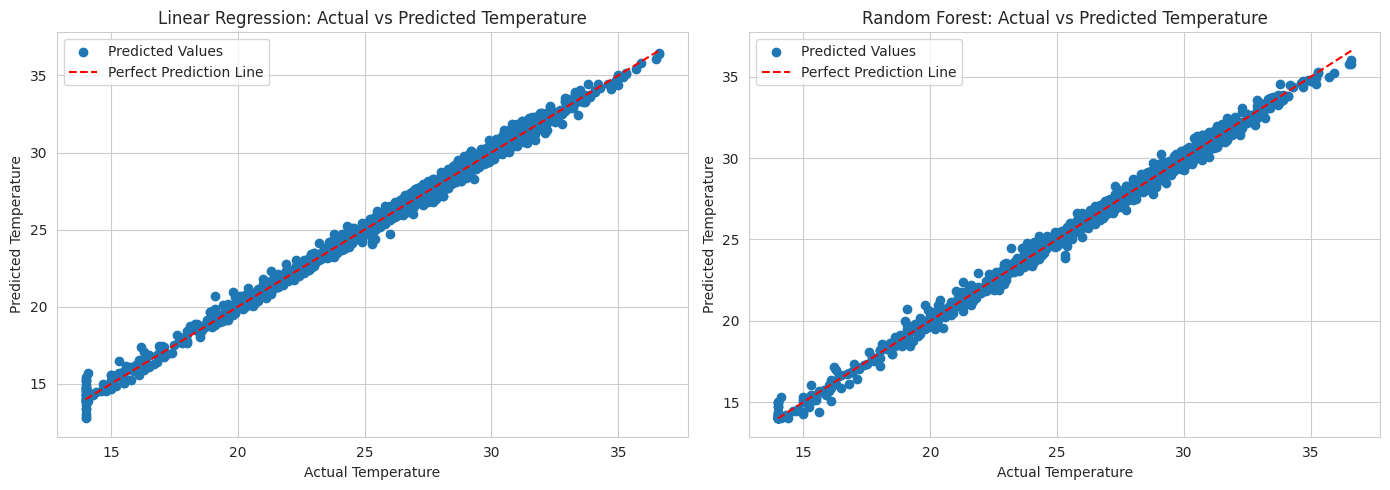

In [91]:
plt.figure(figsize=(14, 5))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test_temp, lr_temp_pred, label="Predicted Values")
plt.plot(
    [y_test_temp.min(), y_test_temp.max()],
    [y_test_temp.min(), y_test_temp.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line")

plt.title("Linear Regression: Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.legend()

# Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test_temp, rf_temp_pred, label="Predicted Values")
plt.plot(
    [y_test_temp.min(), y_test_temp.max()],
    [y_test_temp.min(), y_test_temp.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line")

plt.title("Random Forest: Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.legend()

plt.tight_layout()
plt.show()

Both Linear Regression and Random Forest predictions are very close to the red perfect prediction line. This means both models predict temperature accurately. The points in the Random Forest plot are slightly closer to the line, showing that Random Forest performs a little better for temperature prediction.

###10.2: Evaluate Rainfall Models

In [92]:
# Linear Regression rainfall evaluation
lr_rain_mae = mean_absolute_error(rain_actual_mm, lr_rain_pred_mm)
lr_rain_rmse = np.sqrt(mean_squared_error(rain_actual_mm, lr_rain_pred_mm))
lr_rain_r2 = r2_score(y_test_rain, lr_rain_pred_log)


# Random Forest rainfall evaluation
rf_rain_mae = mean_absolute_error(rain_actual_mm, rf_rain_pred_mm)
rf_rain_rmse = np.sqrt(mean_squared_error(rain_actual_mm, rf_rain_pred_mm))
rf_rain_r2 = r2_score(y_test_rain, rf_rain_pred_log)


print("Linear Regression Rainfall Evaluation")
print("MAE:", lr_rain_mae)
print("RMSE:", lr_rain_rmse)
print("R2 Score:", lr_rain_r2)

print("\nRandom Forest Rainfall Evaluation")
print("MAE:", rf_rain_mae)
print("RMSE:", rf_rain_rmse)
print("R2 Score:", rf_rain_r2)

Linear Regression Rainfall Evaluation
MAE: 62.414077605635384
RMSE: 107.53945107653502
R2 Score: 0.5946672036519961

Random Forest Rainfall Evaluation
MAE: 34.12266828567802
RMSE: 56.10439805369364
R2 Score: 0.8294577878485029


#### 10.2.1: Rainfall Amount Model Comparison

In [93]:
rainfall_results = pd.DataFrame({
    "Model": [ "Linear Regression", "Random Forest"],
    "MAE": [lr_rain_mae, rf_rain_mae],
    "RMSE": [lr_rain_rmse, rf_rain_rmse],
    "R2 Score": [lr_rain_r2, rf_rain_r2]})

print("Rainfall Model Comparison")
print(rainfall_results)

Rainfall Model Comparison
               Model        MAE        RMSE  R2 Score
0  Linear Regression  62.414078  107.539451  0.594667
1      Random Forest  34.122668   56.104398  0.829458


####10.2.2: Best rainfall model

In [94]:
best_rain_model = rainfall_results.sort_values(by="RMSE", ascending=True).iloc[0]

print("Best Rainfall Model:")
print(best_rain_model)

Best Rainfall Model:
Model       Random Forest
MAE             34.122668
RMSE            56.104398
R2 Score         0.829458
Name: 1, dtype: object


####10.2.3: Rainfall actual vs predicted

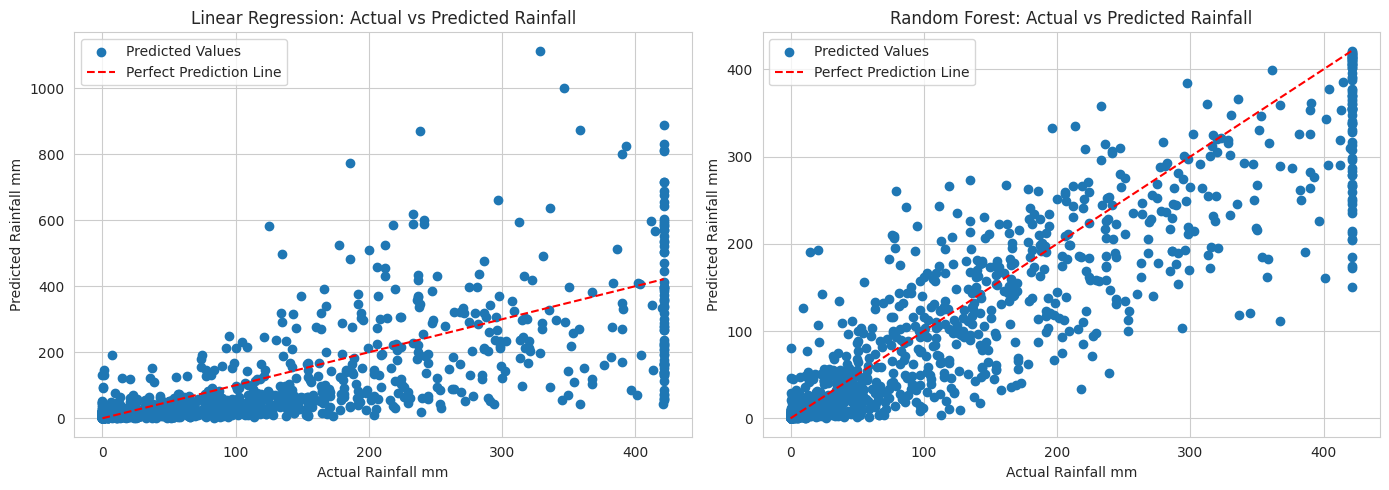

In [95]:
plt.figure(figsize=(14, 5))

# Linear Regression Rainfall
plt.subplot(1, 2, 1)
plt.scatter(rain_actual_mm, lr_rain_pred_mm, label="Predicted Values")

plt.plot(
    [rain_actual_mm.min(), rain_actual_mm.max()],
    [rain_actual_mm.min(), rain_actual_mm.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line")

plt.title("Linear Regression: Actual vs Predicted Rainfall")
plt.xlabel("Actual Rainfall mm")
plt.ylabel("Predicted Rainfall mm")
plt.legend()


# Random Forest Rainfall
plt.subplot(1, 2, 2)
plt.scatter(rain_actual_mm, rf_rain_pred_mm, label="Predicted Values")

plt.plot(
    [rain_actual_mm.min(), rain_actual_mm.max()],
    [rain_actual_mm.min(), rain_actual_mm.max()],
    linestyle="--",
    color="red",
    label="Perfect Prediction Line")

plt.title("Random Forest: Actual vs Predicted Rainfall")
plt.xlabel("Actual Rainfall mm")
plt.ylabel("Predicted Rainfall mm")
plt.legend()

plt.tight_layout()
plt.show()

For rainfall prediction, Random Forest performs better than Linear Regression. In the Linear Regression plot, the points are widely scattered and far from the red perfect prediction line, showing weaker prediction accuracy. In the Random Forest plot, more points are closer to the line, meaning it predicts rainfall more accurately, although rainfall is still harder to predict because it has high variation and extreme values.

###10.3: Evaluate Classification Models

In [96]:
# Logistic Regression accuracy
log_accuracy = accuracy_score(y_test_class, log_pred)

# Random Forest accuracy
rf_class_accuracy = accuracy_score(y_test_class, rf_class_pred)


print("Logistic Regression Rain / No Rain Evaluation")
print("Accuracy:", log_accuracy)

print("\nClassification Report:")
print(classification_report( y_test_class, log_pred, target_names=["No Rain", "Rain"]))

print("\nRandom Forest Rain / No Rain Evaluation")
print("Accuracy:", rf_class_accuracy)

print("\nClassification Report:")
print(classification_report(y_test_class, rf_class_pred, target_names=["No Rain", "Rain"]))

Logistic Regression Rain / No Rain Evaluation
Accuracy: 0.8616666666666667

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.58      0.15      0.24       173
        Rain       0.87      0.98      0.92      1027

    accuracy                           0.86      1200
   macro avg       0.73      0.57      0.58      1200
weighted avg       0.83      0.86      0.83      1200


Random Forest Rain / No Rain Evaluation
Accuracy: 0.9091666666666667

Classification Report:
              precision    recall  f1-score   support

     No Rain       0.74      0.57      0.64       173
        Rain       0.93      0.97      0.95      1027

    accuracy                           0.91      1200
   macro avg       0.83      0.77      0.80      1200
weighted avg       0.90      0.91      0.90      1200



#### 10.3.1: Rain / No Rain Classification Model Comparison

In [97]:
# Create a summary DataFrame storing the final evaluation accuracies for both classifiers
# Accuracy measures the overall percentage of correctly predicted Rain and No-Rain days
classification_results = pd.DataFrame({
    "Model": ["Logistic Regression","Random Forest Classifier"],
    "Accuracy": [log_accuracy, rf_class_accuracy]})

print("Rain / No Rain Classification Model Comparison")
print(classification_results)

Rain / No Rain Classification Model Comparison
                      Model  Accuracy
0       Logistic Regression  0.861667
1  Random Forest Classifier  0.909167


####10.3.2: Best classification model

In [98]:
# Identify the winning classifier by sorting the table by Accuracy in descending order (highest first)
# .iloc[0] extracts the top row containing the model with the maximum predictive performance
best_class_model = classification_results.sort_values(by="Accuracy", ascending=False).iloc[0]

print("Best Rain / No Rain Classification Model:")
print(best_class_model)

Best Rain / No Rain Classification Model:
Model       Random Forest Classifier
Accuracy                    0.909167
Name: 1, dtype: object


### 10.3.3: Confusion matrix

A Confusion Matrix is a tabular layout used to evaluate the performance of a classification model on a set of test data for which the true values are known. It crosses the Actual classes against the Predicted classes, making it easy to see exactly where a model is succeeding or confusing categories.

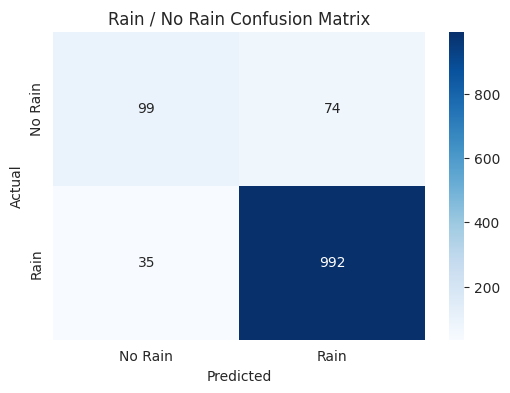

In [99]:
plt.figure(figsize=(6, 4))

# Use Seaborn to plot the confusion matrix data
# - confusion_matrix(): Compares actual test labels vs. model predictions
# - annot=True: Superimposes the actual calculation numbers inside the blocks
# - fmt="d": Displays cell values as clean, whole numbers (integers)
# - cmap="Blues": Applies a clear light-to-dark blue gradient representing frequency density
# - xticklabels/yticklabels: Customizes index markings into easy-to-read text values
sns.heatmap(
    confusion_matrix(y_test_class, rf_class_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"])

plt.title("Rain / No Rain Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the model correctly predicted 99 No Rain cases and 992 Rain cases. It incorrectly predicted 74 No Rain cases as Rain and 35 Rain cases as No Rain. Overall, the model performs well, especially in predicting Rain cases, but it makes some mistakes in identifying No Rain cases.



# 2026 PREDICTION

# 11. 2026 Future Dataset

The trained machine learning models were used to predict weather conditions for 2026. Random Forest was used to predict average temperature and rainfall amount. The classification model was used to predict whether rainfall will occur or not.

In [100]:
# Group the original dataset by both 'city' and 'month' to compute long-term regional averages
# for your key weather attributes, then flatten the index using .reset_index()
future_2026 = df.groupby(["city", "month"])[
    ["tavg", "tmin", "tmax", "prcp", "pres"]].mean().reset_index()

# Set the target prediction year to 2026 across all rows
future_2026["year"] = 2026

# Use the previously fitted categorical encoder to map city names to their identical integer labels
future_2026["city_encoded"] = encoder.transform(future_2026["city"])

# Apply the identical log transformation (np.log1p) to handle skewness in the baseline precipitation rows
future_2026["prcp_log"] = np.log1p(future_2026["prcp"])

# Synthesize a standard 'date' field (YYYY-MM-01) by combining the string values of
# the new year, the baseline month, and a static day code ('01')
future_2026["date"] = pd.to_datetime(
    future_2026["year"].astype(str) + "-" +
    future_2026["month"].astype(str) + "-01")

print(future_2026.head())

   city  month    tavg    tmin    tmax    prcp      pres  year  city_encoded  \
0  Agra      1  14.000   7.500  21.350  26.650  1017.700  2026             0   
1  Agra      2  18.260  11.220  26.160  17.380  1014.760  2026             0   
2  Agra      3  24.925  17.200  32.425  13.575  1011.050  2026             0   
3  Agra      4  30.720  22.420  38.080   2.760  1006.320  2026             0   
4  Agra      5  32.325  26.175  38.425  28.700  1002.625  2026             0   

   prcp_log       date  
0  3.319626 2026-01-01  
1  2.911263 2026-02-01  
2  2.679308 2026-03-01  
3  1.324419 2026-04-01  
4  3.391147 2026-05-01  


### 11.1: Predict 2026 Average Temperature

In [101]:
# Filter the future 2026 dataframe to include only the specific feature columns
X_future_temp = future_2026[temperature_features]

# Pass the structured 2026 features into your trained Random Forest model's .predict() function
# and store the resulting array into a new column named "predicted_tavg"
future_2026["predicted_tavg"] = rf_temp_model.predict(X_future_temp)

print(future_2026[["date", "city", "predicted_tavg"]].head())

        date  city  predicted_tavg
0 2026-01-01  Agra         14.0005
1 2026-02-01  Agra         18.5825
2 2026-03-01  Agra         24.6890
3 2026-04-01  Agra         30.2610
4 2026-05-01  Agra         32.3350


### 11.2: Predict 2026 Rainfall

In [102]:
X_future_rain = future_2026[rainfall_features]

future_2026["predicted_rainfall_mm"] = np.expm1(
    rf_rain_model.predict(X_future_rain))

print(future_2026[["date", "city", "predicted_rainfall_mm"]].head())

        date  city  predicted_rainfall_mm
0 2026-01-01  Agra               9.773836
1 2026-02-01  Agra               1.901702
2 2026-03-01  Agra               6.633547
3 2026-04-01  Agra               3.414187
4 2026-05-01  Agra              46.264664


### 11.3: Predict 2026 Rain / No Rain

In [103]:
# Filter the future 2026 dataframe to isolate the exact feature matrix
# that your classification model expects (e.g., tavg, tmin, tmax, pres, etc.)
X_future_class = future_2026[classification_features]

# Pass the input features into your trained classifier's .predict() function
# to output binary codes (0 for dry days, 1 for wet days)
future_2026["rain_prediction"] = rain_classifier.predict(X_future_class)

# Transform the 0 and 1 integer categories into user-friendly descriptive text
future_2026["rain_prediction_label"] = future_2026["rain_prediction"].map({
    0: "No Rain",
    1: "Rain"})

# Print out a comprehensive validation preview displaying dates, cities,
# regression forecasts (temperature & rainfall), and the final classification label
print(future_2026[
    ["date", "city", "predicted_tavg", "predicted_rainfall_mm", "rain_prediction_label"]].head())

        date  city  predicted_tavg  predicted_rainfall_mm  \
0 2026-01-01  Agra         14.0005               9.773836   
1 2026-02-01  Agra         18.5825               1.901702   
2 2026-03-01  Agra         24.6890               6.633547   
3 2026-04-01  Agra         30.2610               3.414187   
4 2026-05-01  Agra         32.3350              46.264664   

  rain_prediction_label  
0                  Rain  
1                  Rain  
2                  Rain  
3                  Rain  
4                  Rain  


### 11.4 Kochi June 2026 Result

The model was used to predict weather conditions for Kochi in June 2026. The predicted output includes average temperature, rainfall amount in millimeters, and rain/no-rain status.

In [104]:
# Extract the predictive results for Kochi specifically during the month of June (6)
kochi_june_2026 = future_2026[
    (future_2026["city"] == "Kochi") &
    (future_2026["month"] == 6)]

# Print the structured baseline columns alongside your temperature prediction,
# rainfall depth prediction, and binary rain classification label
print(kochi_june_2026[
    [ "date", "city","predicted_tavg","predicted_rainfall_mm","rain_prediction_label"]])

# Isolate the numeric float value for the predicted rainfall millimeter depth from the series
rainfall_value = kochi_june_2026["predicted_rainfall_mm"].values[0]

print("Predicted rainfall in Kochi for June 2026:", round(rainfall_value, 2), "mm")

          date   city  predicted_tavg  predicted_rainfall_mm  \
593 2026-06-01  Kochi         26.4045              395.69091   

    rain_prediction_label  
593                  Rain  
Predicted rainfall in Kochi for June 2026: 395.69 mm


#### 11.4.1: Kochi 2026 Visual

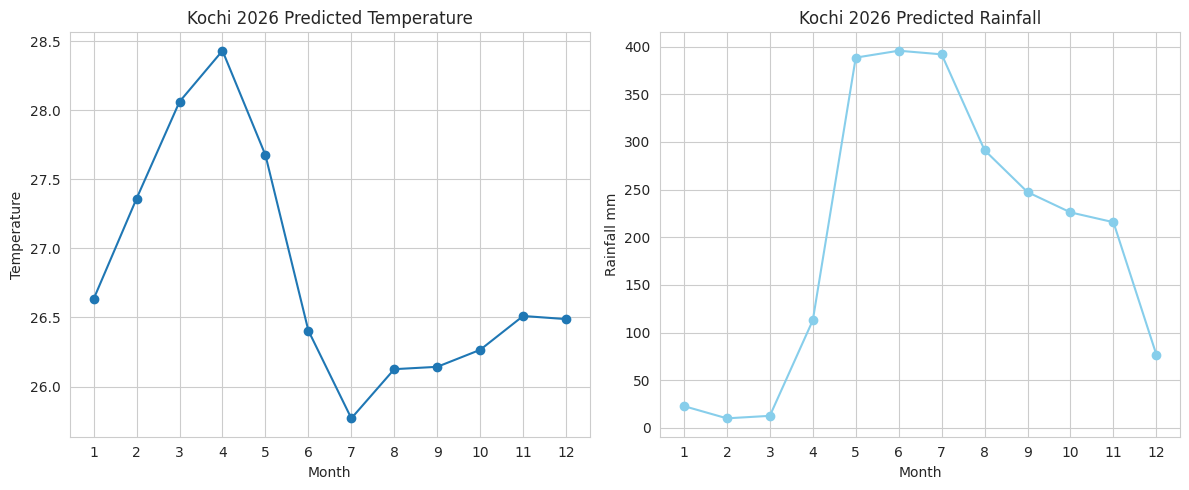

In [105]:
kochi_2026 = future_2026[future_2026["city"] == "Kochi"]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(
    kochi_2026["month"],
    kochi_2026["predicted_tavg"],
    marker="o"
)
plt.title("Kochi 2026 Predicted Temperature")
plt.xlabel("Month")
plt.ylabel("Temperature")
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
plt.plot(
    kochi_2026["month"],
    kochi_2026["predicted_rainfall_mm"],
    marker="o",
    color="skyblue"
)
plt.title("Kochi 2026 Predicted Rainfall")
plt.xlabel("Month")
plt.ylabel("Rainfall mm")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

**Interpretation:**
The 2026 prediction shows that Kochi temperature is expected to be highest around April and lowest around July. Rainfall is predicted to be low from January to March, then increase sharply from May to July. The highest rainfall is expected around June and July, showing a strong monsoon-season pattern.